# Library

In [2]:
import os
from PIL import Image
import tensorflow as tf
import numpy as np
# Visualization
import matplotlib.pyplot as plt
# Albumentations
import albumentations as A
# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import hashlib
from collections import defaultdict ,Counter
import shutil
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint , ReduceLROnPlateau
from keras.applications import EfficientNetB0
from keras.models import Model
from keras.layers import Dense,Flatten,Conv2D, MaxPooling2D ,GlobalAveragePooling2D, BatchNormalization ,Dropout
from pathlib import Path
import random
import cv2

2026-06-07 12:52:01.407202: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780836721.620169      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780836721.680505      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780836722.181557      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780836722.181608      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780836722.181611      57 computation_placer.cc:177] computation placer alr

# Read Data

In [3]:
dataset_path = r"/kaggle/input/datasets/alaafarid/local-dataset/Dataset"
# make subfolder becomes a class label automatically
dataset = tf.keras.utils.image_dataset_from_directory(
 dataset_path,
 batch_size= None,
 shuffle=True #randomize image order
)

Found 20058 files belonging to 61 classes.


I0000 00:00:1780836769.884437      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780836769.890335      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
# Make new variavle for data so we can modify on it
src_path  = r"/kaggle/input/datasets/alaafarid/local-dataset/Dataset" # source path read only
dest_path = r"/kaggle/working/Dataset" #destination path
# copy the dataset from the source folder to the destination folder 
 # if statement to avoid error when runnig code again
if not Path(dest_path).exists():
    print("Copying dataset...")
    shutil.copytree(src_path, dest_path)
    print("Done copying!")

Copying dataset...
Done copying!


In [5]:
# create a list containing all image files inside the folder and its subfolders
image_files = [
    f for f in Path(dest_path).rglob('*')
    if f.is_file()and f.suffix.lower() in {'.jpg', '.jpeg', '.png'}
]

In [6]:
# get image average in the dataset
widths, heights = [], []

for path in image_files:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
print(f"avg width  = {sum(widths)/len(widths):.0f}px")
print(f"avg height = {sum(heights)/len(heights):.0f}px")

avg width  = 334px
avg height = 322px


In [7]:
# get class name (folder name) of each image, then counts how many images exist in each class
classes = [Path(f).parent.name for f in image_files]  # ← iterate image_files #.parent gets folder containing the file,.name gets only the last folder name 

count = Counter(classes)

print(f"Total images : {sum(count.values())}")
print(f"Total classes: {len(count)}\n")
for cls, num in sorted(count.items()):
    print(f"{cls}: {num} images")

Total images : 20056
Total classes: 61

Ahmose I: 285 images
Akhenaten: 443 images
Al-Azhar Mosque: 369 images
Al-Muizz Street: 511 images
Alexandria Library: 324 images
Amenemhat I: 276 images
Amenhotep III: 419 images
Babylon Fortress: 103 images
Bent pyramid for senefru: 401 images
Cairo Citadel: 472 images
Cairo Tower: 219 images
Colossoi of Memnon: 329 images
Dahshur Pyramids: 219 images
Deir el-Bahari: 667 images
Dendera Temple Complex: 151 images
Djoser: 169 images
Edfu Temple: 327 images
Egyptian Museum, Cairo: 134 images
Goddess Isis with her child: 108 images
Hanging Church (St. Virgin Mary Coptic Orthodox Church): 208 images
Hatshepsut face: 144 images
Horemheb: 129 images
Isis Temple at Behbeit El Hagar: 266 images
Karnak Temple: 856 images
Khafre: 163 images
Khafre Pyramid: 444 images
Merneptah: 345 images
Montaza Palace: 358 images
Mortuary Temple of Amenhotep III: 85 images
Narmer (Menes): 174 images
Philae Temple: 463 images
Pyramid_of_Djoser: 172 images
Pyramids of Giz

In [8]:
# find classes less than 100 images
to_remove = [cls for cls, num in count.items() if num < 100]

print(f"Folders to remove: {to_remove},Edfu Temple")

Folders to remove: ['Mortuary Temple of Amenhotep III'],Edfu Temple


In [9]:
#remove classes less than 100 images
for cls, num in count.items():
    if num < 100:
        folder_path = Path(dest_path) / cls
        shutil.rmtree(folder_path)
        shutil.rmtree(r"/kaggle/working/Dataset/Edfu Temple")
        print(f"Deleted: {cls} ({num} images),Edfu Temple")

Deleted: Mortuary Temple of Amenhotep III (85 images),Edfu Temple


In [10]:
# Recount fresh from dest_path after deletion
image_files = [
    f for f in Path(dest_path).rglob('*')
    if f.is_file() and f.suffix.lower() in {'.jpg', '.jpeg', '.png'}
]
count = Counter([Path(f).parent.name for f in image_files])

avg = sum(count.values()) / len(count)

print(f"Total images    : {sum(count.values())}")
print(f"Total classes   : {len(count)}")
print(f"Avg images/class: {avg:.0f}")

Total images    : 19644
Total classes   : 59
Avg images/class: 333


In [11]:
# classes need augmentation
aug_classes = [cls for cls, num in count.items() if num < 400]

print(f"Folders to augment: {aug_classes}")

Folders to augment: ['Colossoi of Memnon', 'Statue of Tutankhamun with Ankhesenamun', 'Alexandria Library', 'Pyramids of Giza', 'Sobekneferu', 'Horemheb', 'Ramessum', 'Statue of King Zoser', 'White Desert', 'Khafre', 'Tutankhamun (King Tut)', 'Amenemhat I', 'Isis Temple at Behbeit El Hagar', 'Narmer (Menes)', 'Babylon Fortress', 'Dendera Temple Complex', 'Ahmose I', 'Montaza Palace', 'Pyramid_of_Djoser', 'Hanging Church (St. Virgin Mary Coptic Orthodox Church)', 'Merneptah', 'Temple_of_Isis_in_Philae', 'Saqqara Pyramid', 'Serapeum of Saqqara', 'Egyptian Museum, Cairo', 'Al-Azhar Mosque', 'Ramesses III', 'Temple of Seti I at Abydos', 'khufu statue', 'Cairo Tower', 'Dahshur Pyramids', 'The Great Temple of Ramesses II', 'Goddess Isis with her child', 'Sesostris III', 'Djoser', 'Temple_of_Kom_Ombo', 'amenhotep iii and tiye', 'Hatshepsut face', 'Temple of Hatshepsut', 'menkaure pyramid']


In [12]:
# ── 2. Define augmentation pipeline
augment = A.Compose([
 A.HorizontalFlip(p=0.5),
 A.VerticalFlip(p=0.5),
 A.Rotate(limit=45, p=0.5),
 A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
 A.GaussianBlur(blur_limit=3, p=0.2),
 A.HueSaturationValue(p=0.3)
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [13]:
target_count = 400

# Refresh count
image_files = [
    f for f in Path(dest_path).rglob('*')
    if f.is_file() and f.suffix.lower() in {'.jpg', '.jpeg', '.png'}
]
count = Counter([Path(f).parent.name for f in image_files])

for class_name, current_count in count.items():
    class_path = Path(dest_path) / class_name
    needed = target_count - current_count

    if needed <= 0:
        print(f"✓ {class_name}: {current_count} images — ok")
        continue

    print(f"↑ {class_name}: {current_count} → adding {needed} augmented images")

    # Only pick original images (not previously augmented ones)
    originals = [
        f for f in class_path.iterdir()
        if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}
        and not f.stem.startswith('aug_')
    ]

    i = 0
    while i < needed:
        src = random.choice(originals)
        image = cv2.imread(str(src))
        if image is None:
            continue
        try:
            aug_img = augment(image=image)["image"]
            cv2.imwrite(str(class_path / f"aug_{i}.jpg"), aug_img)
            i += 1
        except Exception as e:
            print(f"  Warning: {e}")

print("\nDone. Recounting...")

# Recount
image_files = [
    f for f in Path(dest_path).rglob('*')
    if f.is_file() and f.suffix.lower() in {'.jpg', '.jpeg', '.png'}
]
count = Counter([Path(f).parent.name for f in image_files])
for cls, num in sorted(count.items()):
    print(f"  {cls}: {num} images")

↑ Colossoi of Memnon: 329 → adding 71 augmented images
↑ Statue of Tutankhamun with Ankhesenamun: 105 → adding 295 augmented images
✓ Khafre Pyramid: 444 images — ok
↑ Alexandria Library: 324 → adding 76 augmented images
✓ Ras Muhammad National Park: 416 images — ok
↑ Pyramids of Giza: 383 → adding 17 augmented images
✓ Qaitbay Citadel: 515 images — ok
↑ Sobekneferu: 216 → adding 184 augmented images
↑ Horemheb: 129 → adding 271 augmented images
✓ Temple of Horus at Edfu: 568 images — ok
✓ Sphinx: 762 images — ok
✓ Al-Muizz Street: 511 images — ok
✓ Ramses II (Ramses the Great): 574 images — ok
↑ Ramessum: 353 → adding 47 augmented images
↑ Statue of King Zoser: 137 → adding 263 augmented images
✓ Deir el-Bahari: 667 images — ok
✓ Cairo Citadel: 472 images — ok
↑ White Desert: 242 → adding 158 augmented images
↑ Khafre: 163 → adding 237 augmented images
✓ Wadi Natrun Monasteries: 440 images — ok
↑ Tutankhamun (King Tut): 399 → adding 1 augmented images
↑ Amenemhat I: 276 → adding 124 a

# Build Model

In [14]:
SEED       = 42
BATCH_SIZE = 32
IMG_SIZE   = (224, 224)
dest_path  = r"/kaggle/working/Dataset"

labels = [f.parent.name for f in image_files]

train_files, temp_files, train_labels, temp_labels = train_test_split(
    image_files, labels, test_size=0.30, stratify=labels, random_state=SEED
)
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels, test_size=0.50, stratify=temp_labels, random_state=SEED
)

class_names  = sorted(set(labels))
num_classes  = len(class_names)
label_to_idx = {c: i for i, c in enumerate(class_names)}

print(f"Train : {len(train_files)}")
print(f"Val   : {len(val_files)}")
print(f"Test  : {len(test_files)}")

Train : 18405
Val   : 3944
Test  : 3944


In [15]:
load = lambda path, label: (
    tf.image.resize(
        tf.image.decode_image(tf.io.read_file(path), channels=3, expand_animations=False),
        IMG_SIZE
    ),
    label
)

# ── Online augmentation applied only to train
def augment_train(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0, 255)
    return image, label

train_ds = (
    tf.data.Dataset.from_tensor_slices(
        ([str(f) for f in train_files], [label_to_idx[l] for l in train_labels])
    )
    .map(load,          num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment_train, num_parallel_calls=tf.data.AUTOTUNE)  # ← train only
    .shuffle(1000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices(
        ([str(f) for f in val_files], [label_to_idx[l] for l in val_labels])
    )
    .map(load, num_parallel_calls=tf.data.AUTOTUNE)           # ← no augmentation
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices(
        ([str(f) for f in test_files], [label_to_idx[l] for l in test_labels])
    )
    .map(load, num_parallel_calls=tf.data.AUTOTUNE)           # ← no augmentation
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [16]:
# train_ds = tf.data.Dataset.from_tensor_slices(([str(f) for f in train_files], [label_to_idx[l] for l in train_labels]))
# val_ds   = tf.data.Dataset.from_tensor_slices(([str(f) for f in val_files],   [label_to_idx[l] for l in val_labels]))
# test_ds  = tf.data.Dataset.from_tensor_slices(([str(f) for f in test_files],  [label_to_idx[l] for l in test_labels]))

# load = lambda path, label: (
#     tf.image.resize(tf.image.decode_image(tf.io.read_file(path), channels=3, expand_animations=False), IMG_SIZE),
#     label
# )

# train_ds = train_ds.map(load, num_parallel_calls=tf.data.AUTOTUNE).shuffle(1000, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
# val_ds   = val_ds.map(load,   num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
# test_ds  = test_ds.map(load,  num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

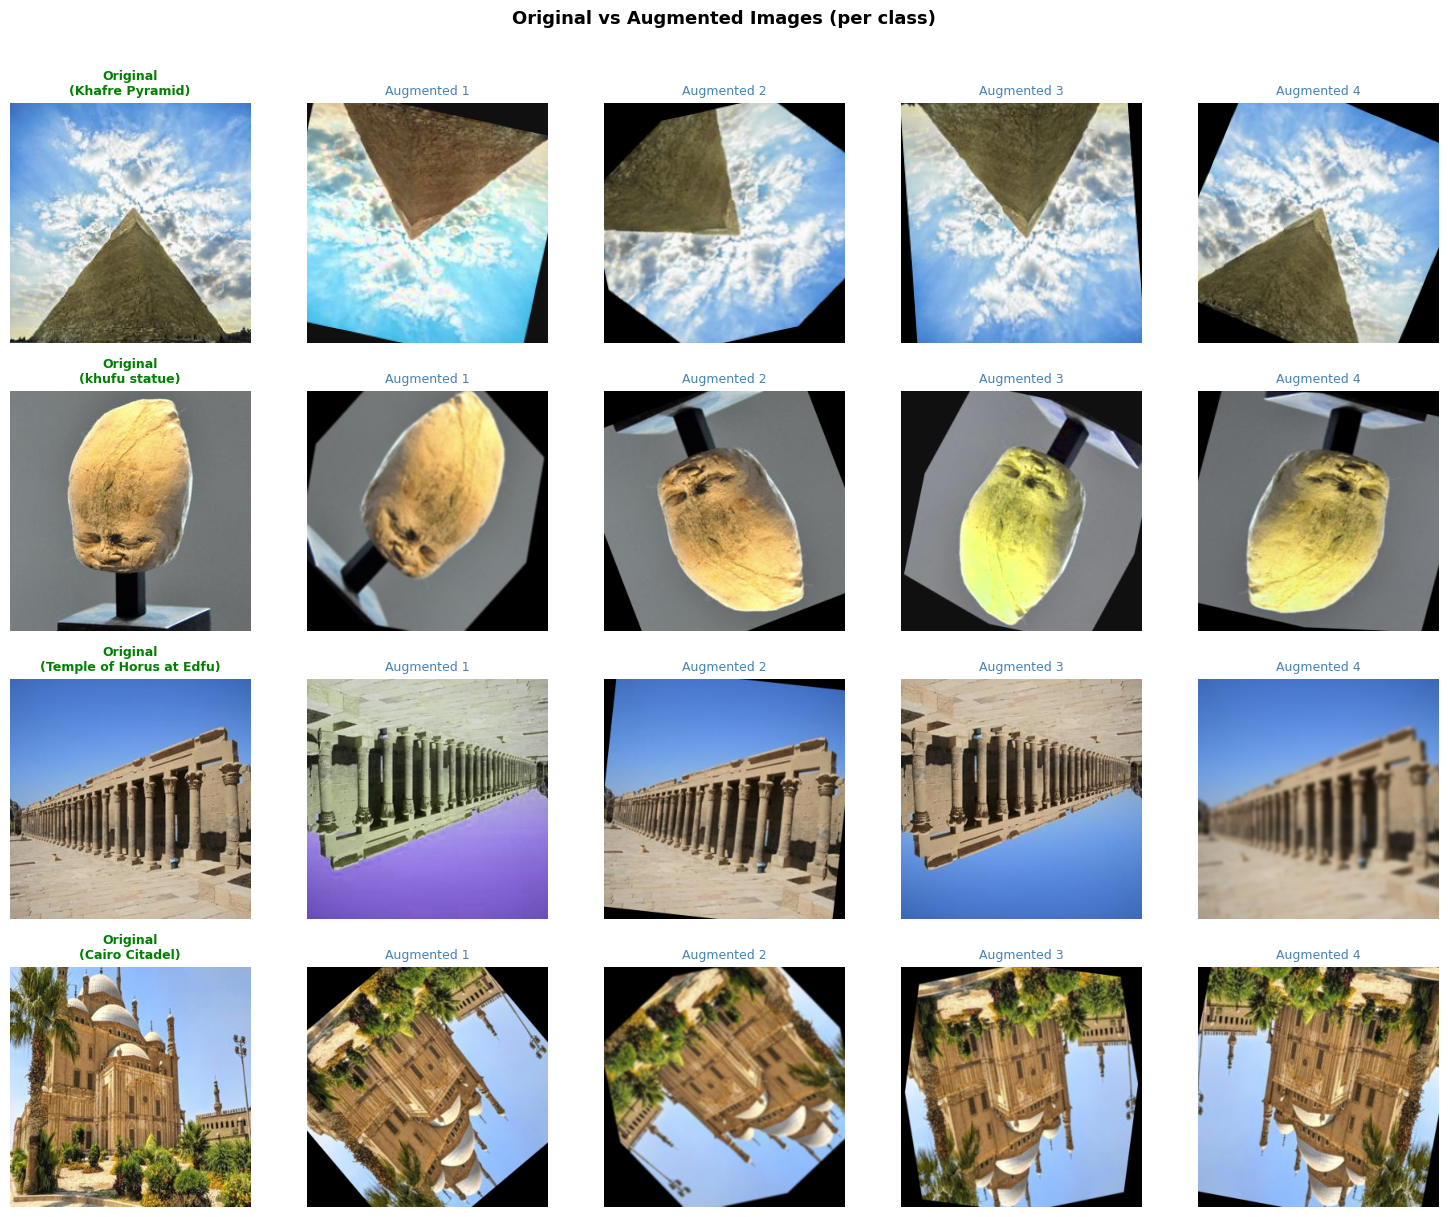

In [17]:
def show_augmentation_samples(dest_path, augment, num_classes=4, num_augments=4):
    """Show original vs augmented images for a few random classes."""
    
    class_dirs = [d for d in Path(dest_path).iterdir() if d.is_dir()]
    sampled_classes = random.sample(class_dirs, min(num_classes, len(class_dirs)))
    
    fig, axes = plt.subplots(
        len(sampled_classes), num_augments + 1,
        figsize=(3 * (num_augments + 1), 3 * len(sampled_classes))
    )
    
    # Handle single class edge case
    if len(sampled_classes) == 1:
        axes = [axes]
    
    for row, class_dir in enumerate(sampled_classes):
        # Pick one random original image
        original_images = [
            f for f in class_dir.iterdir()
            if f.suffix.lower() in {'.jpg', '.jpeg', '.png'} and not f.stem.startswith('aug_')
        ]
        src = random.choice(original_images)
        image = cv2.imread(str(src))
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Column 0 → original
        axes[row][0].imshow(image_rgb)
        axes[row][0].set_title(f"Original\n({class_dir.name})", fontsize=9, color='green', fontweight='bold')
        axes[row][0].axis('off')
        
        # Columns 1..N → augmented versions
        for col in range(1, num_augments + 1):
            aug_img = augment(image=image)["image"]
            aug_rgb = cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB)
            axes[row][col].imshow(aug_rgb)
            axes[row][col].set_title(f"Augmented {col}", fontsize=9, color='steelblue')
            axes[row][col].axis('off')
    
    plt.suptitle("Original vs Augmented Images (per class)", fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

show_augmentation_samples(dest_path, augment, num_classes=4, num_augments=4)

In [18]:
# ── Build EfficientNetB0 base
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
# ── Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# ── Build head
x = base_model.output
x = GlobalAveragePooling2D()(x)      # better than Flatten for EfficientNet
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(num_classes, activation='softmax')(x)

In [20]:
model = Model(inputs=base_model.input, outputs=output_layer)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,423,134 (16.87 MB)

 Trainable params: 371,003 (1.42 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [21]:
# ── Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    '/kaggle/working/best_efficientnet.keras',
    monitor='val_loss',
    save_best_only=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

In [22]:
# ── Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
# ── Phase 1: Train head only
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

Epoch 1/50


I0000 00:00:1780836977.956775     138 service.cc:152] XLA service 0x7f0d500c3380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780836977.956836     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780836977.956844     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780836980.023962     138 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-07 12:56:27.070982: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 12:56:27.215458: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 12:56:27.551666: E external/local_xl

574/576 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2948 - loss: 2.8565

2026-06-07 12:57:07.812420: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 12:57:07.947741: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 12:57:08.258867: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 12:57:08.399064: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 12:57:09.151780: E external/local_xla/xla/stream_

576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2952 - loss: 2.8544

2026-06-07 12:57:31.241976: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 12:57:31.379092: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 12:57:31.680182: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 12:57:31.820533: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 12:57:32.573083: E external/local_xla/xla/stream_

576/576 ━━━━━━━━━━━━━━━━━━━━ 90s 106ms/step - accuracy: 0.2954 - loss: 2.8533 - val_accuracy: 0.6362 - val_loss: 1.2704 - learning_rate: 0.0010
Epoch 2/50
576/576 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - accuracy: 0.5500 - loss: 1.5843 - val_accuracy: 0.6798 - val_loss: 1.0769 - learning_rate: 0.0010
Epoch 3/50
576/576 ━━━━━━━━━━━━━━━━━━━━ 31s 52ms/step - accuracy: 0.6124 - loss: 1.3504 - val_accuracy: 0.7127 - val_loss: 0.9665 - learning_rate: 0.0010
Epoch 4/50
576/576 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - accuracy: 0.6459 - loss: 1.2042 - val_accuracy: 0.7325 - val_loss: 0.8967 - learning_rate: 0.0010
Epoch 5/50
576/576 ━━━━━━━━━━━━━━━━━━━━ 32s 53ms/step - accuracy: 0.6711 - loss: 1.1002 - val_accuracy: 0.7457 - val_loss: 0.8465 - learning_rate: 0.0010
Epoch 6/50
576/576 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - accuracy: 0.6948 - loss: 1.0306 - val_accuracy: 0.7497 - val_loss: 0.8132 - learning_rate: 0.0010
Epoch 7/50
576/576 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - accuracy: 0.7035 - loss: 0.978

In [24]:
# ── Phase 2: Fine-tune last 50 layers
for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

Epoch 1/100
576/576 ━━━━━━━━━━━━━━━━━━━━ 91s 104ms/step - accuracy: 0.6784 - loss: 1.1525 - val_accuracy: 0.7994 - val_loss: 0.7365 - learning_rate: 1.0000e-05
Epoch 2/100
576/576 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.7357 - loss: 0.9125 - val_accuracy: 0.8131 - val_loss: 0.6878 - learning_rate: 1.0000e-05
Epoch 3/100
576/576 ━━━━━━━━━━━━━━━━━━━━ 36s 60ms/step - accuracy: 0.7628 - loss: 0.8007 - val_accuracy: 0.8187 - val_loss: 0.6559 - learning_rate: 1.0000e-05
Epoch 4/100
576/576 ━━━━━━━━━━━━━━━━━━━━ 36s 60ms/step - accuracy: 0.7776 - loss: 0.7170 - val_accuracy: 0.8281 - val_loss: 0.6391 - learning_rate: 1.0000e-05
Epoch 5/100
576/576 ━━━━━━━━━━━━━━━━━━━━ 36s 60ms/step - accuracy: 0.7901 - loss: 0.6742 - val_accuracy: 0.8306 - val_loss: 0.6271 - learning_rate: 1.0000e-05
Epoch 6/100
576/576 ━━━━━━━━━━━━━━━━━━━━ 36s 60ms/step - accuracy: 0.7965 - loss: 0.6422 - val_accuracy: 0.8327 - val_loss: 0.6114 - learning_rate: 1.0000e-05
Epoch 7/100
576/576 ━━━━━━━━━━━━━━━━━━━━ 36s 

In [38]:
# ── Predict
y_pred = model.predict(test_ds)
y_pred = y_pred.argmax(axis=1)
print(y_pred)

124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step
[47 34 51 ... 20 13 22]


In [39]:
# ── Evaluate
loss, accuracy = model.evaluate(test_ds)
print(f"\nTest Loss    : {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")


124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8595 - loss: 0.5203

Test Loss    : 0.5071
Test Accuracy: 86.61%


In [40]:
y_true = np.concatenate([y for _, y in test_ds], axis=0)

# ── Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))

                                                         precision    recall  f1-score   support

                                               Ahmose I       0.82      0.90      0.86        60
                                              Akhenaten       0.85      0.86      0.86        66
                                        Al-Azhar Mosque       0.89      0.92      0.90        60
                                        Al-Muizz Street       0.90      0.93      0.92        76
                                     Alexandria Library       0.92      0.93      0.93        60
                                            Amenemhat I       0.92      0.93      0.93        60
                                          Amenhotep III       0.80      0.44      0.57        63
                                       Babylon Fortress       0.98      0.98      0.98        60
                               Bent pyramid for senefru       0.84      0.90      0.87        60
                             

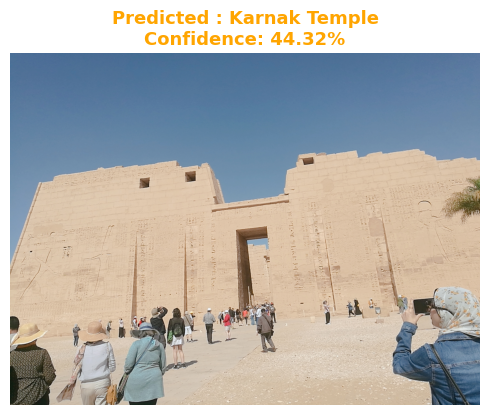


Rank  Class                           Confidence
------------------------------------------------
1     Karnak Temple                       44.32%
2     Temple of Habu                      35.12%
3     Philae Temple                        4.19%


In [48]:
# ── Test on a New Image (run after the classification report)

# ▼▼▼  Change this to your image path  ▼▼▼
IMAGE_PATH = r"/kaggle/input/datasets/alaafarid/test-set/20200301_100834_219.jpg"
# ▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲

# ── Load & preprocess
img_raw   = tf.io.read_file(IMAGE_PATH)
img       = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
img       = tf.image.resize(img, IMG_SIZE)        # (300, 300, 3)
img_batch = tf.expand_dims(img, axis=0)           # (1, 300, 300, 3)

# ── Predict
probs      = model.predict(img_batch, verbose=0)  # shape (1, num_classes)
pred_idx   = int(np.argmax(probs, axis=1)[0])
pred_class = class_names[pred_idx]
confidence = float(probs[0][pred_idx]) * 100

# ── Display image with prediction title
display_img = cv2.cvtColor(cv2.imread(IMAGE_PATH), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(display_img)
plt.axis('off')
plt.title(
    f'Predicted : {pred_class}\nConfidence: {confidence:.2f}%',
    fontsize=13, fontweight='bold',
    color='green' if confidence >= 70 else 'orange'
)
plt.tight_layout()
plt.show()

# ── Top-3 confidence table
print(f"\n{'Rank':<6}{'Class':<30}{'Confidence':>12}")
print('-' * 48)
for rank, idx in enumerate(np.argsort(probs[0])[::-1][:3], 1):
    print(f"{rank:<6}{class_names[idx]:<30}{probs[0][idx]*100:>11.2f}%")

In [49]:
 import pickle
 with open('model.pkl', 'wb') as f:
     pickle.dump(model, f)

In [50]:
 model.save('.h5')

In [31]:
# SEED       = 42
# BATCH_SIZE = 32
# IMG_SIZE   = (224, 224)
# dest_path  = r"/kaggle/working/Dataset"


# # ── Train 70%
# train_ds = tf.keras.utils.image_dataset_from_directory(
#     dest_path,
#     validation_split=0.30,
#     subset="training",
#     seed=SEED,
#     image_size=IMG_SIZE,
#     batch_size=BATCH_SIZE
# )

# # ── Val + Test 30%
# val_test_ds = tf.keras.utils.image_dataset_from_directory(
#     dest_path,
#     validation_split=0.30,
#     subset="validation",
#     seed=SEED,
#     image_size=IMG_SIZE,
#     batch_size=BATCH_SIZE
# )


# class_names = train_ds.class_names
# num_classes = len(class_names)

# val_batches = tf.data.experimental.cardinality(val_test_ds)
# val_ds  = val_test_ds.take(val_batches // 2)
# test_ds = val_test_ds.skip(val_batches // 2)


# train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
# val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
# test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)

# # ── Verify
# print(f"Train batches : {tf.data.experimental.cardinality(train_ds)}")
# print(f"Val batches   : {tf.data.experimental.cardinality(val_ds)}")
# print(f"Test batches  : {tf.data.experimental.cardinality(test_ds)}")

In [32]:
# # ── Freeze ONLY base_model
# base_model.trainable = False

# # ── Build full model using Functional API
# inputs = tf.keras.Input(shape=IMG_SIZE + (3,))

# #  EfficientNet has built-in preprocessing — NO need for Rescaling
# x = base_model(inputs, training=False)
# x = tf.keras.layers.GlobalAveragePooling2D()(x)
# x = tf.keras.layers.BatchNormalization()(x)
# x = tf.keras.layers.Dense(256, activation='relu')(x)
# x = tf.keras.layers.Dropout(0.3)(x)
# outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

# model = tf.keras.Model(inputs, outputs)

In [33]:
# model.compile(
#     optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# model.summary()


In [34]:
# # ── Callbacks
# callbacks = [
#     tf.keras.callbacks.EarlyStopping(
#         monitor='val_loss',
#         patience=3,
#         restore_best_weights=True
#     ),
#     tf.keras.callbacks.ReduceLROnPlateau(
#         monitor='val_loss',
#         factor=0.2,
#         patience=2
#     ),
#     tf.keras.callbacks.ModelCheckpoint(
#         '/kaggle/working/best_efficientnet.keras',
#         monitor='val_accuracy',
#         save_best_only=True
#     )
# ]


In [35]:
# # ── Phase 1: Train head only
# print("=" * 40)
# print("Phase 1: Training head only...")
# print("=" * 40)
# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=EPOCHS,
#     callbacks=callbacks
# )

In [36]:
# # ── Phase 2: Fine-tune last 20 layers
# print("=" * 40)
# print("Phase 2: Fine-tuning last 20 layers...")
# print("=" * 40)
# base_model.trainable = True
# for layer in base_model.layers[:-20]:
#     layer.trainable = False

# model.compile(
#     optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5),  # lower lr
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# history_fine = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=EPOCHS,
#     callbacks=callbacks
# )

In [37]:
# # ── Evaluate on test set
# loss, accuracy = model.evaluate(test_ds)
# print(f"\nTest Loss    : {loss:.4f}")
# print(f"Test Accuracy: {accuracy*100:.2f}%")